In [4]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/US_Accidents_March23.csv',
    nrows=50000
)

print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [5]:
df = df[[
    "Severity",
    "Start_Time",
    "Weather_Condition",
    "State",
    "Start_Lat",
    "Start_Lng",
    "Sunrise_Sunset"
]]

print(df.head())
print(df.isnull().sum())

   Severity           Start_Time Weather_Condition State  Start_Lat  \
0         3  2016-02-08 05:46:00        Light Rain    OH  39.865147   
1         2  2016-02-08 06:07:59        Light Rain    OH  39.928059   
2         2  2016-02-08 06:49:27          Overcast    OH  39.063148   
3         3  2016-02-08 07:23:34     Mostly Cloudy    OH  39.747753   
4         2  2016-02-08 07:39:07     Mostly Cloudy    OH  39.627781   

   Start_Lng Sunrise_Sunset  
0 -84.058723          Night  
1 -82.831184          Night  
2 -84.032608          Night  
3 -84.205582          Night  
4 -84.188354            Day  
Severity               0
Start_Time             0
Weather_Condition    603
State                  0
Start_Lat              0
Start_Lng              0
Sunrise_Sunset         0
dtype: int64


In [6]:
df.dropna(inplace=True)
print(df.shape)
print(df.isnull().sum())

(49397, 7)
Severity             0
Start_Time           0
Weather_Condition    0
State                0
Start_Lat            0
Start_Lng            0
Sunrise_Sunset       0
dtype: int64


In [7]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["Hour"] = df["Start_Time"].dt.hour

print(df.head())

   Severity          Start_Time Weather_Condition State  Start_Lat  Start_Lng  \
0         3 2016-02-08 05:46:00        Light Rain    OH  39.865147 -84.058723   
1         2 2016-02-08 06:07:59        Light Rain    OH  39.928059 -82.831184   
2         2 2016-02-08 06:49:27          Overcast    OH  39.063148 -84.032608   
3         3 2016-02-08 07:23:34     Mostly Cloudy    OH  39.747753 -84.205582   
4         2 2016-02-08 07:39:07     Mostly Cloudy    OH  39.627781 -84.188354   

  Sunrise_Sunset  Hour  
0          Night     5  
1          Night     6  
2          Night     6  
3          Night     7  
4            Day     7  


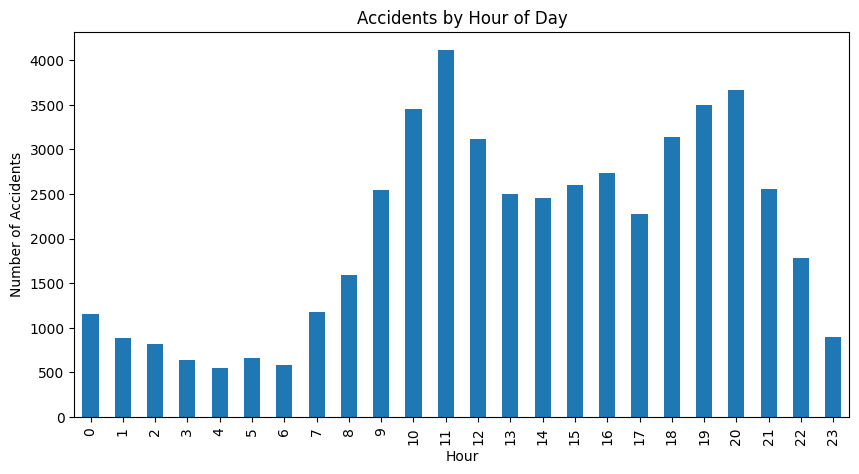

In [8]:
import matplotlib.pyplot as plt

df["Hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

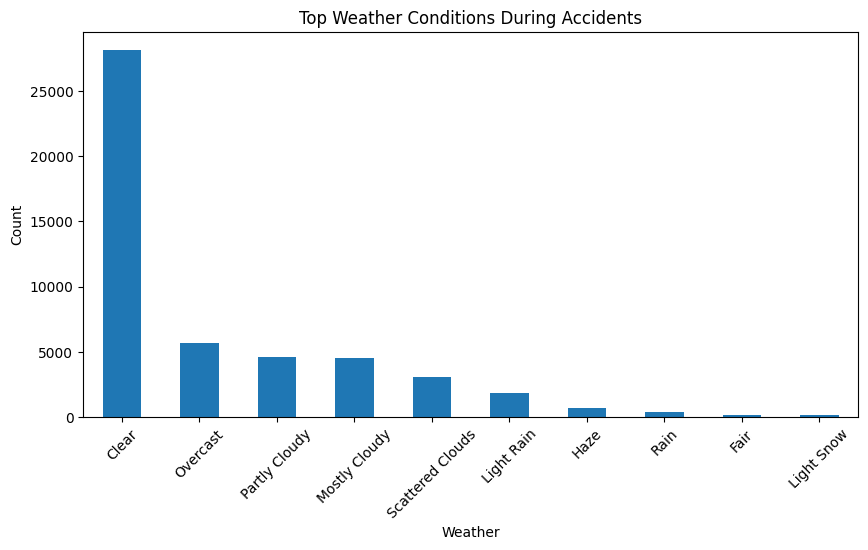

In [9]:
df["Weather_Condition"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

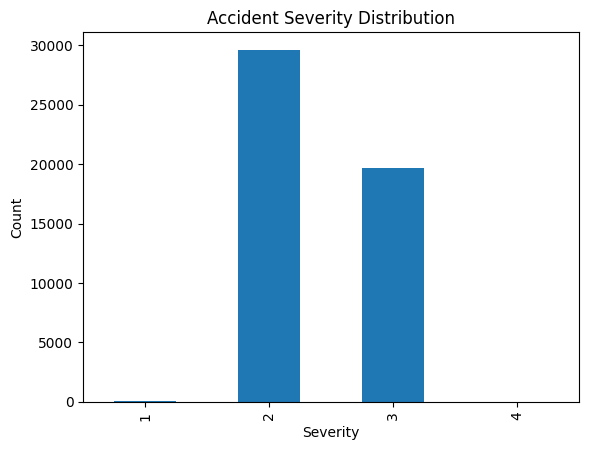

In [10]:
df["Severity"].value_counts().sort_index().plot(kind="bar")

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

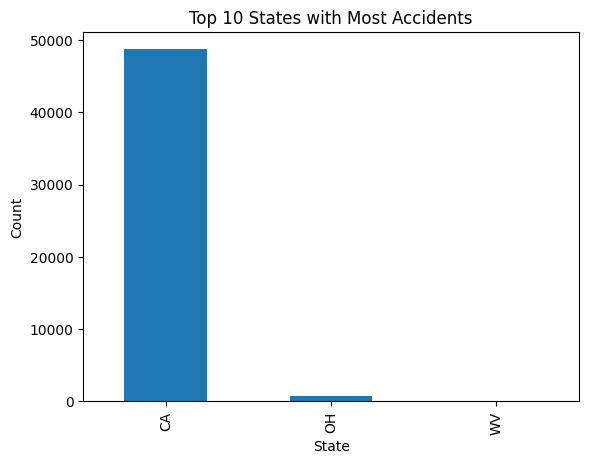

In [11]:
df["State"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 States with Most Accidents")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

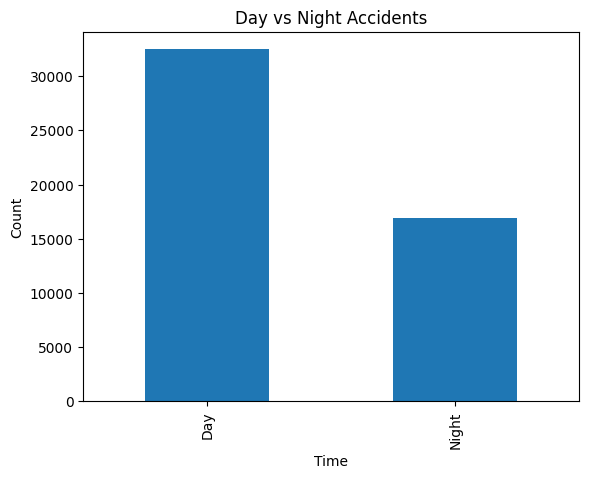

In [12]:
df["Sunrise_Sunset"].value_counts().plot(kind="bar")

plt.title("Day vs Night Accidents")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

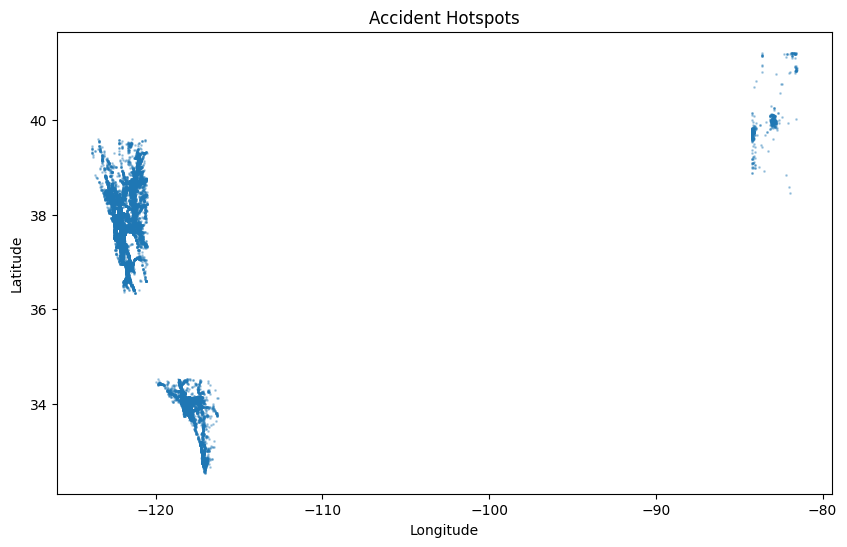

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Start_Lng"],
    df["Start_Lat"],
    s=1,
    alpha=0.3
)

plt.title("Accident Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()